<a href="https://colab.research.google.com/github/busetas/Roketsan_Sensor/blob/main/08_1D_EKF_SLAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**SLAM (Simultaneous Localization and Mapping - Eş Zamanlı Konumlandırma ve Haritalama)**

Bu notebook'ta, konuyu anlamaya çalışmak ve odaklanmak için karmaşık matris türevleri ve kütüphaneler yerine 1D (Tek Boyutlu) EKF-SLAM ile başlayalım.

İlk adımda kod yazmadan önce probleme yaklaşımı netleştirelim.

**Adım 1: Dünyayı ve Problemi Tanımlama**

1. Dünya ve Robot Modeli

Robot: Tek bir doğru üzerinde ($x$ ekseni) sağa/sola hareket eden 1D bir araç.

Deniz Fenerleri / Landmark'lar: Yerleri önceden bilinmeyen, sabit duran nesneler ($m_1, m_2, \dots$).

Amacımız:

i. Robotun nerede olduğunu tahmin etmek ($x$).L


ii. Landmark'ların nerede olduğunu tahmin etmek ($m_1, m_2, \dots$).

Kritik Nokta: Yukarıdaki maddelerin her ikisini de aynı anda ve gürültülü sensör verilerine rağmen yapmak.

2. Durum Vektörü (State Vector)

EKF-SLAM'in temel mantığı, robotun konumu ile haritadaki landmark'ların konumunu tek bir vektörde birleştirmektir.Örneğin, 2 adet landmark'ımız varsa durum vektörümüz ($\mathbf{x}$) şöyle görünür:
$$\mathbf{x} = \begin{bmatrix} x_r \\ m_1 \\ m_2 \end{bmatrix}$$

Burada:
- $x_r$: Robotun $x$ konum tahmini.
- $m_1, m_2$: Landmark 1 ve 2'nin konum tahminleri.

3. Belirsizlik: Kovaryans Matrisi ($\mathbf{P}$)

Hataları ve değişkenler arasındaki korelasyonu tutmak için bir Kovaryans Matrisi kullanırız.$$\mathbf{P} = \begin{bmatrix}  \sigma_{r}^2 & \sigma_{r,m1} & \sigma_{r,m2} \\ \sigma_{m1,r} & \sigma_{m1}^2 & \sigma_{m1,m2} \\ \sigma_{m2,r} & \sigma_{m2}^2 & \sigma_{m2}^2  \end{bmatrix}$$

- Köşegen elemanlar ($\sigma_{r}^2, \sigma_{m1}^2, \dots$): İlgili değişkenin kendi konumundaki belirsizlik (varyans).

- Köşegen dışı elemanlar ($\sigma_{r,m1}, \dots$): Robotun konumu ile landmark konumu arasındaki ilişki (korelasyon).

SLAM'i sadece bağımsız filtrelerden ayıran Sihirli Kısım burasıdır:
- Robot hareket ettikçe veya bir landmark'ı gördükçe, diğer landmark'lar hakkındaki bilgimiz de güncellenir.

-----------------------


**Nasıl Bir Yol İzleyeceğiz?**

**Adım 1: Problemi ve Matematiksel Durum Vektörünü Tanımlama (Yukarıda yaptığımız işlemler)**

**Adım 2: Tahmin (Prediction / Motion) Adımını ve Kodunu Yazma**

**Adım 3: Güncelleme (Update / Measurement) Adımını ve Kodunu Yazma**

**Adım 4: Tam Çalışan Python Simülasyonu ve Görselleştirme**

----------------------------


**Adım 2: Tahmin Adımı (Prediction / Motion Update)**

Bu adımda robot hareket eder.

Matematiksel olarak robotun yeni konumunu tahmin ederiz ve hareketin getirdiği belirsizliği (gürültüyü) sistem kovaryansına ekleriz.

Matematiksel Mantık:

Robot $u$ kadar bir komutla ilerlediğinde (odometri/tekerlek kodlayıcı verisi):

1. Durum Tahmini ($\mathbf{x}$):

- Robotun yeni konumu: $x_r \leftarrow x_r + u$

- Landmark'lar sabit durduğu için $m_1, m_2$ konumları değişmez.

2. Kovaryans Güncellemesi ($\mathbf{P}$):

- Hareket kusursuz değildir; işin içine hareket gürültüsü ($Q$) girer.

- Bu gürültü sadece robotun konumuyla ilişkili varyansa eklenir:$$P_{0,0} \leftarrow P_{0,0} + Q$$

- Landmark'ların kendi varyansları ve var olan korelasyonlar bu adımdan doğrudan etkilenmez.

Aşağıdaki kod bloğunda durumu ilklendiren ve Tahmin (Predict) fonksiyonunu gerçekleştiren yapıyı kurguluyoruz:

In [1]:
import numpy as np

class EKFSLAM1D:
    def __init__(self, initial_x_r, num_landmarks, motion_noise):
        """
        initial_x_r : Robotun başlangıç konumu tahmini
        num_landmarks : Haritadaki landmark sayısı
        motion_noise : Hareket gürültüsünün varyansı (Q)
        """
        self.num_landmarks = num_landmarks
        self.Q = motion_noise  # Hareket gürültüsü

        # 1. Durum Vektörü [x_r, m_1, m_2, ...]
        # Robot konumu biliniyor, landmark'lar başlangıçta 0 varsayılıyor.
        self.x = np.zeros(1 + num_landmarks)
        self.x[0] = initial_x_r

        # 2. Kovaryans Matrisi (P)
        self.P = np.zeros((1 + num_landmarks, 1 + num_landmarks))

        # Robotun başlangıç konum belirsizliği düşük (örneğin 0.1)
        self.P[0, 0] = 0.1

        # Landmark'ların başlangıç konumlarını BİLMİYORUZ.
        # Bu yüzden onların belirsizliklerini (varyanslarını) çok yüksek başlatıyoruz.
        for i in range(1, 1 + num_landmarks):
            self.P[i, i] = 1000.0

    def predict(self, u):
        """
        u: Robotun yapması istenen hareket miktarı (örneğin +2.0 birim)
        """
        # A. Durum Tahmini (Sadece robot hareket eder)
        self.x[0] += u

        # B. Belirsizlik Artışı (Gürültü ekleme)
        # Sadece robotun varyansına (P[0,0]) hareket gürültüsü Q eklenir
        self.P[0, 0] += self.Q


# --- Küçük bir test yapalım ---
if __name__ == "__main__":
    # 2 adet landmark olsun, hareket gürültüsü Q = 0.5
    slam = EKFSLAM1D(initial_x_r=0.0, num_landmarks=2, motion_noise=0.5)

    print("--- BAŞLANGIÇ DURUMU ---")
    print("x (Durum Vektörü) :", slam.x)
    print("P[0,0] (Robot Var):", slam.P[0, 0])

    # Robot 2.0 birim sağa hareket ediyor
    slam.predict(u=2.0)

    print("\n--- TAHMİN (PREDICT) SONRASI ---")
    print("x (Durum Vektörü) :", slam.x)
    print("P[0,0] (Robot Var):", slam.P[0, 0])

--- BAŞLANGIÇ DURUMU ---
x (Durum Vektörü) : [0. 0. 0.]
P[0,0] (Robot Var): 0.1

--- TAHMİN (PREDICT) SONRASI ---
x (Durum Vektörü) : [2. 0. 0.]
P[0,0] (Robot Var): 0.6


**Dikkat Edilmesi Gereken Hususlar**

- Landmark Belirsizliği Neden $1000.0$?

Başlangıçta haritada landmark'ların nerede olduğuna dair hiçbir fikrimiz yok (Infinitely Uncertain).

- P Matrisinde Neden Sadece $P[0,0]$ Artıyor?

Çünkü robot hareket ettikçe kendi konumu hakkındaki belirsizliği artar; ancak hareket etmek, henüz görmediği ya da sabit duran landmark'ların konum belirsizliğini artırmaz.


**Adım 3: Güncelleme Adımı (Measurement / Update)**

Ölçüm Güncellemesi (Measurement / Update) EKF-SLAM'in kalbidir. Robot sensöründen (örneğin mesafe ölçer) gelen veriyle hem kendi konumunu hem de landmark'ın konumunu iyileştirir.

Matematiksel Mantık

1. Robot $i$. landmark'a olan mesafeyi ölçsün ($z_i$).

- Beklenen Ölçüm Modelimiz ($h(x)$):Mesafe, landmark konumu ile robot konumu arasındaki farktır:$$h(x) = m_i - x_r$$

- Yenilik / İnovasyon ($y$):Gerçek ölçüm ($z$) ile beklenen ölçüm ($h(x)$) arasındaki fark:$$y = z - (m_i - x_r)$$

- Ölçüm Jacobiyeni ($H$):Mesafe fonksiyonunun durum değişkenlerine ($[x_r, m_1, m_2, \dots]$) göre türevi:$$H = \begin{bmatrix} \frac{\partial h}{\partial x_r} & \frac{\partial h}{\partial m_1} & \dots \end{bmatrix} = \begin{bmatrix} -1 & 0 & \dots & 1 & \dots & 0 \end{bmatrix}$$(Robot için $-1$, ölçülen $i$. landmark için $+1$, diğerleri için $0$)

- Kalman Kazancı ($K$):Ölçüm gürültüsü $R$ olmak üzere:$$S = H P H^T + R$$$$K = P H^T S^{-1}$$Güncelleme:$$\mathbf{x} \leftarrow \mathbf{x} + K y$$$$\mathbf{P} \leftarrow (I - K H) \mathbf{P}$$


Python Kodu (Adım 3)

Sınıfımıza update metodunu ekliyoruz:

In [2]:
import numpy as np

class EKFSLAM1D:
    def __init__(self, initial_x_r, num_landmarks, motion_noise, measurement_noise):
        """
        measurement_noise: Sensör ölçüm gürültüsünün varyansı (R)
        """
        self.num_landmarks = num_landmarks
        self.Q = motion_noise
        self.R = measurement_noise  # Sensör gürültüsü

        # 1. Durum Vektörü [x_r, m_1, m_2, ...]
        self.x = np.zeros(1 + num_landmarks)
        self.x[0] = initial_x_r

        # 2. Kovaryans Matrisi (P)
        self.P = np.zeros((1 + num_landmarks, 1 + num_landmarks))
        self.P[0, 0] = 0.1
        for i in range(1, 1 + num_landmarks):
            self.P[i, i] = 1000.0

    def predict(self, u):
        """ Motion Update / Prediction """
        self.x[0] += u
        self.P[0, 0] += self.Q

    def update(self, z, landmark_idx):
        """
        z            : Ölçülen mesafe (sensör okuması)
        landmark_idx : Ölçülen landmark'ın indeksi (0, 1, 2...)
        """
        # Durum vektöründe bu landmark'ın tutulduğu dizin
        lm_map_idx = 1 + landmark_idx

        # 1. Beklenen Ölçüm (h)
        # Eğer landmark henüz hiç görülmediyse, ilk ölçümle ilklendir
        if self.P[lm_map_idx, lm_map_idx] >= 500.0:
            self.x[lm_map_idx] = self.x[0] + z
            self.P[lm_map_idx, lm_map_idx] = self.P[0, 0] + self.R
            return

        expected_z = self.x[lm_map_idx] - self.x[0]

        # 2. İnovasyon (y)
        y = z - expected_z

        # 3. Ölçüm Jacobiyeni (H)
        H = np.zeros((1, 1 + self.num_landmarks))
        H[0, 0] = -1.0         # d(h)/d(x_r)
        H[0, lm_map_idx] = 1.0 # d(h)/d(m_i)

        # 4. Kalman Kazancı (K)
        S = H @ self.P @ H.T + self.R  # Ölçüm Kovaryansı (1x1)
        K = self.P @ H.T @ np.linalg.inv(S) # (N x 1)

        # 5. Durum Vektörünü ve Kovaryansı Güncelle
        self.x = self.x + (K * y).flatten()
        I = np.identity(len(self.x))
        self.P = (I - K @ H) @ self.P


# --- Test Alanı ---
if __name__ == "__main__":
    # 1 landmark, hareket gürültüsü Q=0.2, sensör gürültüsü R=0.1
    slam = EKFSLAM1D(initial_x_r=0.0, num_landmarks=1, motion_noise=0.2, measurement_noise=0.1)

    # Adım A: İlerle
    slam.predict(u=5.0)
    print("İlerleme Sonrası Tahminî Robot Konumu:", slam.x[0])

    # Adım B: Landmark_0'a olan mesafeyi 2.1 birim ölçtük (İlk Görüş)
    slam.update(z=2.1, landmark_idx=0)
    print("İlk Ölçüm Sonrası Landmark 0 Tahmini:", slam.x[1])

    # Adım C: Tekrar ölçtük, bu sefer 1.9 birim geldi (Güncelleme)
    slam.update(z=1.9, landmark_idx=0)
    print("İkinci Ölçüm Sonrası Robot Konumu    :", slam.x[0])
    print("İkinci Ölçüm Sonrası Landmark Tahmini :", slam.x[1])
    print("\nGüncellenmiş P Matrisi:\n", np.round(slam.P, 3))

İlerleme Sonrası Tahminî Robot Konumu: 5.0
İlk Ölçüm Sonrası Landmark 0 Tahmini: 7.1
İkinci Ölçüm Sonrası Robot Konumu    : 5.075
İkinci Ölçüm Sonrası Landmark Tahmini : 7.0

Güncellenmiş P Matrisi:
 [[0.188 0.15 ]
 [0.15  0.2  ]]


Kritik Sorular ve Hususlar

- if self.P[lm_map_idx, lm_map_idx] >= 500.0: Bloğu Neden Var?

Landmark'ı ilk defa gördüğümüzde lineerleştirme yapamayız; direkt olarak robota olan mesafeyi kullanarak haritaya ekleriz (Landmark Initialization).

- Kovaryans Matrisindeki ($P$) Çapraz Elemanlara Ne Oldu?

Güncelleme sonrasında $P_{0,1}$ ve $P_{1,0}$ değerlerinin sıfırdan farklı hale geldiğini görecekler. Bu, "Robot'un konumu artık Landmark'ın konumuna bağlıdır" demektir.

--------------------

Matematiksel ve algoritmik kısmı tamamladık! Adım 4'e geçip, hareket simülasyonu, rasgele sensör gürültüleri ve matplotlib grafik çıktısıyla tam çalışan bir demo oluşturalım...

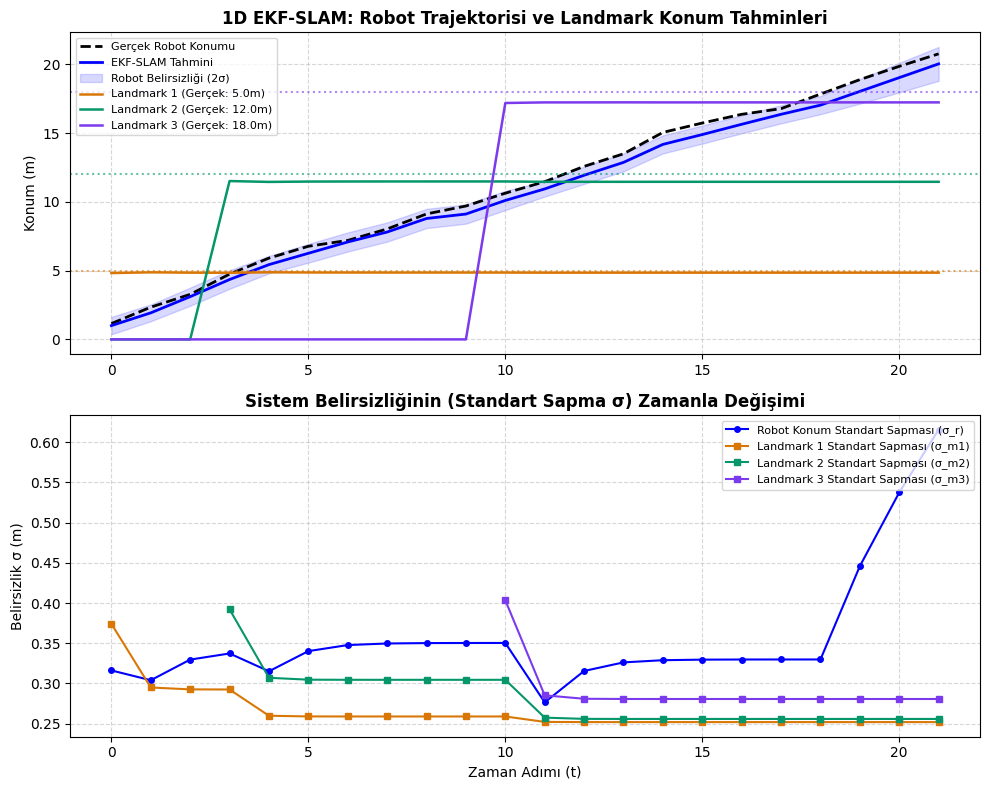

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Rastgelelik sonuçlarının her çalıştırmada aynı çıkması için
np.random.seed(42)

class EKFSLAM1D:
    def __init__(self, initial_x_r, num_landmarks, motion_noise, measurement_noise):
        self.num_landmarks = num_landmarks
        self.Q = motion_noise       # Hareket varyansı (Q)
        self.R = measurement_noise  # Sensör varyansı (R)

        # 1. Durum Vektörü [x_r, m_0, m_1, ...]
        self.x = np.zeros(1 + num_landmarks)
        self.x[0] = initial_x_r

        # 2. Kovaryans Matrisi (P)
        self.P = np.zeros((1 + num_landmarks, 1 + num_landmarks))
        self.P[0, 0] = 0.01  # Başlangıç konumu belirsizliği düşük
        for i in range(1, 1 + num_landmarks):
            self.P[i, i] = 1000.0  # Görülmemiş landmark'lar için yüksek belirsizlik

    def predict(self, u):
        """ Hareket modeli tahmin adımı """
        self.x[0] += u
        self.P[0, 0] += self.Q

    def update(self, z, landmark_idx):
        """ Ölçüm güncelleme adımı """
        lm_map_idx = 1 + landmark_idx

        # İlk defa görünüyorsa haritaya ekle (Ilklendirme)
        if self.P[lm_map_idx, lm_map_idx] >= 500.0:
            self.x[lm_map_idx] = self.x[0] + z
            self.P[lm_map_idx, lm_map_idx] = self.P[0, 0] + self.R
            return

        # Beklenen ölçüm h(x) = m_i - x_r
        expected_z = self.x[lm_map_idx] - self.x[0]

        # İnovasyon y = z - h(x)
        y = z - expected_z

        # Ölçüm Jacobiyeni (H)
        H = np.zeros((1, 1 + self.num_landmarks))
        H[0, 0] = -1.0
        H[0, lm_map_idx] = 1.0

        # Kalman Kazancı (K) ve Güncelleme
        S = H @ self.P @ H.T + self.R
        K = self.P @ H.T @ np.linalg.inv(S)

        self.x = self.x + (K * y).flatten()
        I = np.identity(len(self.x))
        self.P = (I - K @ H) @ self.P


# ==========================================
# 1. SİMÜLASYON AYARLARI VE ÇALIŞTIRMA
# ==========================================
true_landmarks = np.array([5.0, 12.0, 18.0])  # Gerçek landmark konumları (m)
num_landmarks = len(true_landmarks)

motion_noise_std = 0.3      # Gerçek tekerlek gürültüsü (standart sapma)
sensor_noise_std = 0.2      # Gerçek sensör gürültüsü (standart sapma)
sensor_range = 8.0          # Sensörün maksimum menzili (m)

slam = EKFSLAM1D(
    initial_x_r=0.0,
    num_landmarks=num_landmarks,
    motion_noise=motion_noise_std**2,
    measurement_noise=sensor_noise_std**2
)

true_robot_x = 0.0
odometry_step = 1.0
time_steps = 22

# Veri Kayıt Dizileri
history = {
    'time': [], 'true_robot': [], 'est_robot': [], 'robot_std': [],
    'est_landmarks': [[] for _ in range(num_landmarks)],
    'landmark_stds': [[] for _ in range(num_landmarks)]
}

# Zaman Döngüsü
for t in range(time_steps):
    # Gerçek Dünyada Hareket (Gürültülü fizik)
    actual_motion = odometry_step + np.random.normal(0, motion_noise_std)
    true_robot_x += actual_motion

    # SLAM Tahmini (Odometri komutu u = 1.0)
    slam.predict(u=odometry_step)

    # Sensör Ölçümü ve SLAM Güncellemesi
    for idx, true_lm in enumerate(true_landmarks):
        true_dist = true_lm - true_robot_x
        if 0 < true_dist <= sensor_range:
            noisy_z = true_dist + np.random.normal(0, sensor_noise_std)
            slam.update(noisy_z, idx)

    # Geçmiş verileri kaydet
    history['time'].append(t)
    history['true_robot'].append(true_robot_x)
    history['est_robot'].append(slam.x[0])
    history['robot_std'].append(np.sqrt(slam.P[0, 0]))

    for i in range(num_landmarks):
        history['est_landmarks'][i].append(slam.x[1 + i])
        history['landmark_stds'][i].append(np.sqrt(slam.P[1 + i, 1 + i]))


# ==========================================
# 2. GÖRSELLEŞTİRME (MATPLOTLIB)
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), dpi=100)
times = np.array(history['time'])

# --- GRAFİK 1: Konum Tahminleri ve Trajektörü ---
# Gerçek ve Tahmini Robot Konumu
ax1.plot(times, history['true_robot'], 'k--', label='Gerçek Robot Konumu', linewidth=2)
ax1.plot(times, history['est_robot'], 'b-', label='EKF-SLAM Tahmini', linewidth=2)

# Robot Belirsizlik Bandı (2-sigma = %95 güven aralığı)
robot_est = np.array(history['est_robot'])
robot_std = np.array(history['robot_std'])
ax1.fill_between(times, robot_est - 2*robot_std, robot_est + 2*robot_std,
                 color='blue', alpha=0.15, label='Robot Belirsizliği (2σ)')

# Landmark Tahminleri ve Gerçek Değerleri
colors = ['#D97706', '#059669', '#7C3AED']
for i in range(num_landmarks):
    ax1.axhline(true_landmarks[i], color=colors[i], linestyle=':', alpha=0.6)
    lm_est = np.array(history['est_landmarks'][i])
    ax1.plot(times, lm_est, color=colors[i], linestyle='-', linewidth=1.8,
             label=f'Landmark {i+1} (Gerçek: {true_landmarks[i]}m)')

ax1.set_title("1D EKF-SLAM: Robot Trajektorisi ve Landmark Konum Tahminleri", fontweight='bold')
ax1.set_ylabel("Konum (m)")
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper left', fontsize=8)

# --- GRAFİK 2: Belirsizliğin (Standart Sapma) Zamanla Değişimi ---
ax2.plot(times, history['robot_std'], 'b-o', markersize=4,
         label='Robot Konum Standart Sapması (σ_r)', linewidth=1.5)

for i in range(num_landmarks):
    lm_std = np.array(history['landmark_stds'][i])
    # Görsel anlaşılırlık için ilklendirilmemiş yüksek değerleri maskele
    lm_std_plot = np.where(lm_std > 5.0, np.nan, lm_std)
    ax2.plot(times, lm_std_plot, color=colors[i], marker='s', markersize=4,
             linestyle='-', label=f'Landmark {i+1} Standart Sapması (σ_m{i+1})', linewidth=1.5)

ax2.set_title("Sistem Belirsizliğinin (Standart Sapma σ) Zamanla Değişimi", fontweight='bold')
ax2.set_xlabel("Zaman Adımı (t)")
ax2.set_ylabel("Belirsizlik σ (m)")
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

**Simülasyon Çıktısının Analizi ve Yorumlanması**

Yukarıdaki simülasyonun ürettiği iki grafikten öğrenilecek temel SLAM ilkeleri şunlardır:

1. Görüş Alanına Giriş ve İlklendirme (Initialization):

Üst grafikte Landmark 3'ün ($18\text{ m}$) tahmini $t=10$ anına kadar $0\text{ m}$ çizgisinde durur.

Robot menzile girdiği an EKF-SLAM bu landmark'ı haritaya ekler.

2. Kovaryans Düşüşü (Uncertainty Reduction):

Alt grafikte, robot bir landmark'ı her gördüğünde robotun ve o landmark'ın belirsizlik değeri ($\sigma$) aniden aşağı yönlü kırılma yaşar.

3. Açık Döngü Sürüklenmesi (Dead Reckoning Drift):

$t=18$ sonrasında robot hiçbir landmark'ı göremez hale gelir ($20\text{ m}$'nin üzerine çıktığında).Alt grafikteki mavi çizginin ($t>18$) yukarı doğru hızla tırmandığı görülür. Bu, "Sensörsüz/Landmark'sız hareket ettikçe belirsizlik sonsuza doğru birikir" kuralının somut göstergesidir.